In [1]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms
from torchvision.utils import make_grid, save_image

import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

OUTPUT_DIR = "/kaggle/working/week5_7_conditional_gan_anime_faces"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/results", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/samples", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/models", exist_ok=True)

Using device: cuda


In [2]:
LABELS_CSV = "/kaggle/input/datasets/parakramjangir/labels/labels.csv"

labels_df = pd.read_csv(LABELS_CSV)

print("Shape:", labels_df.shape)
print(labels_df.head())
print(labels_df["label"].value_counts())

Shape: (63565, 2)
                                          image_path    label
0  /kaggle/input/datasets/splcher/animefacedatase...  class_2
1  /kaggle/input/datasets/splcher/animefacedatase...  class_0
2  /kaggle/input/datasets/splcher/animefacedatase...  class_3
3  /kaggle/input/datasets/splcher/animefacedatase...  class_1
4  /kaggle/input/datasets/splcher/animefacedatase...  class_5
label
class_3    13352
class_2    12497
class_5    10527
class_0    10119
class_1     8889
class_4     8181
Name: count, dtype: int64


In [3]:
label_names = sorted(labels_df["label"].unique())

label_to_idx = {label: idx for idx, label in enumerate(label_names)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

labels_df["label_idx"] = labels_df["label"].map(label_to_idx)

num_classes = len(label_names)

print("Number of classes:", num_classes)
print(label_to_idx)

Number of classes: 6
{'class_0': 0, 'class_1': 1, 'class_2': 2, 'class_3': 3, 'class_4': 4, 'class_5': 5}


In [4]:
image_size = 64

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

class LabelledAnimeFaceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image_path = self.data.iloc[idx]["image_path"]
        label = self.data.iloc[idx]["label_idx"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [5]:
dataset = LabelledAnimeFaceDataset(labels_df, transform=transform)

class_counts = labels_df["label_idx"].value_counts().sort_index().values
class_weights = 1.0 / class_counts

sample_weights = labels_df["label_idx"].map(
    lambda x: class_weights[x]
).values

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

batch_size = 128

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

images, labels = next(iter(loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Sample labels:", labels[:10])

Image batch shape: torch.Size([128, 3, 64, 64])
Label batch shape: torch.Size([128])
Sample labels: tensor([2, 5, 2, 0, 0, 3, 4, 5, 3, 3])


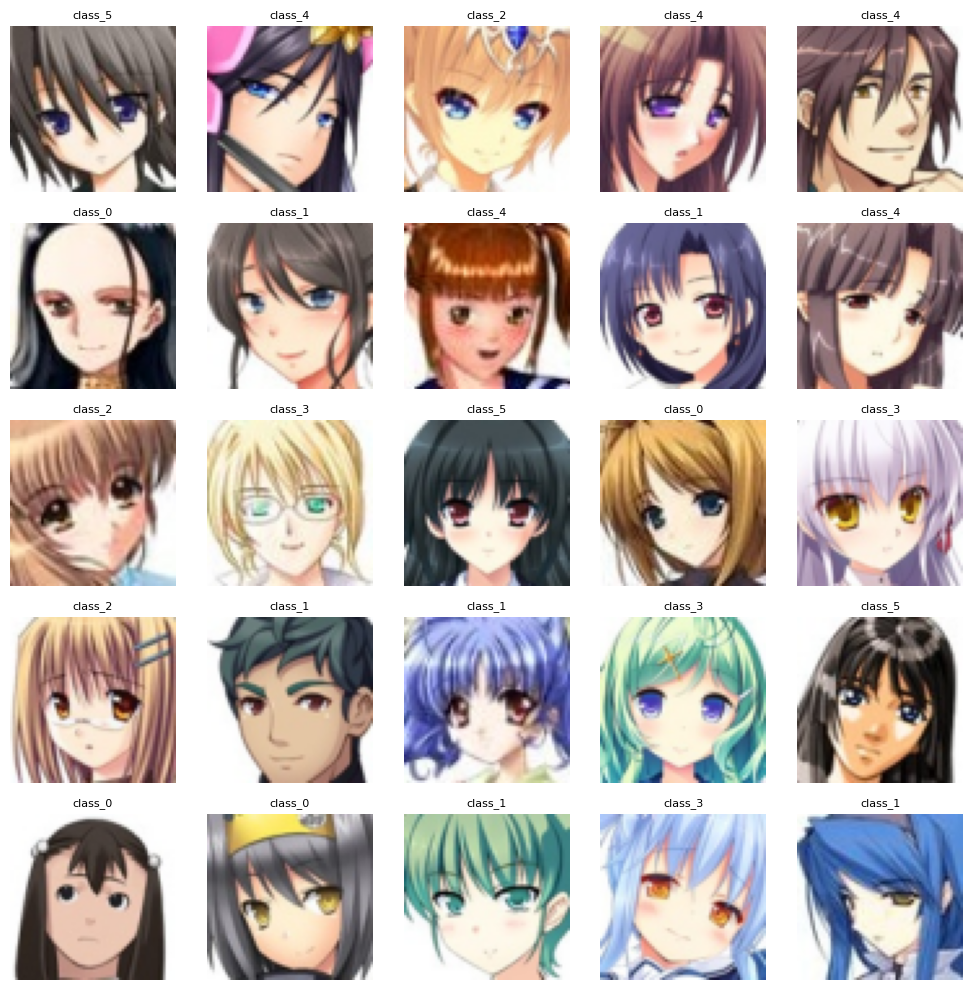

Saved: /kaggle/working/week5_7_conditional_gan_anime_faces/results/week5_7_real_labelled_samples.png


In [6]:
def denormalize(img):
    img = img * 0.5 + 0.5
    return img.clamp(0, 1)

real_images, real_labels = next(iter(loader))

plt.figure(figsize=(10, 10))

for i in range(25):
    img = denormalize(real_images[i]).permute(1, 2, 0).numpy()

    plt.subplot(5, 5, i + 1)
    plt.imshow(img)
    plt.title(idx_to_label[real_labels[i].item()], fontsize=8)
    plt.axis("off")

plt.tight_layout()

real_sample_path = f"{OUTPUT_DIR}/results/week5_7_real_labelled_samples.png"
plt.savefig(real_sample_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", real_sample_path)

In [7]:
latent_dim = 100
embedding_dim = 100
channels = 3

class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim, num_classes, embedding_dim, channels):
        super().__init__()

        self.label_embedding = nn.Embedding(num_classes, embedding_dim)

        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim + embedding_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_embed = self.label_embedding(labels)
        x = torch.cat([noise, label_embed], dim=1)
        x = x.view(x.size(0), x.size(1), 1, 1)
        return self.main(x)

In [8]:
class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes, image_size, channels):
        super().__init__()

        self.label_embedding = nn.Embedding(num_classes, image_size * image_size)

        self.main = nn.Sequential(
            nn.Conv2d(channels + 1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, images, labels):
        label_embed = self.label_embedding(labels)
        label_embed = label_embed.view(labels.size(0), 1, image_size, image_size)

        x = torch.cat([images, label_embed], dim=1)
        return self.main(x).view(-1, 1)

In [9]:
def weights_init(m):
    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G = ConditionalGenerator(
    latent_dim=latent_dim,
    num_classes=num_classes,
    embedding_dim=embedding_dim,
    channels=channels
).to(device)

D = ConditionalDiscriminator(
    num_classes=num_classes,
    image_size=image_size,
    channels=channels
).to(device)

G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCELoss()

optimizer_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

print("Generator and Discriminator initialized.")

Generator and Discriminator initialized.


In [10]:
samples_per_class = 8

fixed_labels = []

for class_idx in range(num_classes):
    fixed_labels += [class_idx] * samples_per_class

fixed_labels = torch.tensor(fixed_labels, dtype=torch.long).to(device)
fixed_noise = torch.randn(len(fixed_labels), latent_dim).to(device)

print("Fixed noise:", fixed_noise.shape)
print("Fixed labels:", fixed_labels.shape)

Fixed noise: torch.Size([48, 100])
Fixed labels: torch.Size([48])


In [11]:
def save_generated_samples(epoch):
    G.eval()

    with torch.no_grad():
        fake_images = G(fixed_noise, fixed_labels)

    grid = make_grid(
        fake_images,
        nrow=samples_per_class,
        normalize=True
    )

    save_path = f"{OUTPUT_DIR}/samples/epoch_{epoch:03d}.png"
    save_image(grid, save_path)

    G.train()
    print("Saved:", save_path)

In [12]:
num_epochs = 40

G_losses = []
D_losses = []

real_label_value = 0.9
fake_label_value = 0.0

for epoch in range(1, num_epochs + 1):
    epoch_g_loss = 0
    epoch_d_loss = 0

    for real_images, labels in tqdm(loader, desc=f"Epoch {epoch}/{num_epochs}"):
        real_images = real_images.to(device)
        labels = labels.to(device)

        current_batch_size = real_images.size(0)

        real_targets = torch.full(
            (current_batch_size, 1),
            real_label_value,
            device=device
        )

        fake_targets = torch.full(
            (current_batch_size, 1),
            fake_label_value,
            device=device
        )

        # ---------------------
        # Train Discriminator
        # ---------------------
        D.zero_grad()

        real_output = D(real_images, labels)
        d_real_loss = criterion(real_output, real_targets)

        noise = torch.randn(current_batch_size, latent_dim, device=device)
        fake_images = G(noise, labels)

        fake_output = D(fake_images.detach(), labels)
        d_fake_loss = criterion(fake_output, fake_targets)

        d_loss = d_real_loss + d_fake_loss
        d_loss.backward()
        optimizer_D.step()

        # ---------------------
        # Train Generator
        # ---------------------
        G.zero_grad()

        output = D(fake_images, labels)
        g_loss = criterion(output, real_targets)

        g_loss.backward()
        optimizer_G.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()

    avg_d_loss = epoch_d_loss / len(loader)
    avg_g_loss = epoch_g_loss / len(loader)

    D_losses.append(avg_d_loss)
    G_losses.append(avg_g_loss)

    print(
        f"Epoch [{epoch}/{num_epochs}] "
        f"D Loss: {avg_d_loss:.4f} "
        f"G Loss: {avg_g_loss:.4f}"
    )

    if epoch == 1 or epoch % 5 == 0 or epoch == num_epochs:
        save_generated_samples(epoch)

Epoch 1/40: 100%|██████████| 497/497 [01:51<00:00,  4.44it/s]


Epoch [1/40] D Loss: 1.2584 G Loss: 4.4201
Saved: /kaggle/working/week5_7_conditional_gan_anime_faces/samples/epoch_001.png


Epoch 2/40: 100%|██████████| 497/497 [01:31<00:00,  5.43it/s]


Epoch [2/40] D Loss: 0.9866 G Loss: 3.8867


Epoch 3/40: 100%|██████████| 497/497 [01:31<00:00,  5.46it/s]


...

Epoch [38/40] D Loss: 0.5141 G Loss: 4.1315


Epoch 39/40: 100%|██████████| 497/497 [01:30<00:00,  5.47it/s]


Epoch [39/40] D Loss: 0.5278 G Loss: 4.2645


Epoch 40/40: 100%|██████████| 497/497 [01:30<00:00,  5.47it/s]

Epoch [40/40] D Loss: 0.5163 G Loss: 4.1615
Saved: /kaggle/working/week5_7_conditional_gan_anime_faces/samples/epoch_040.png


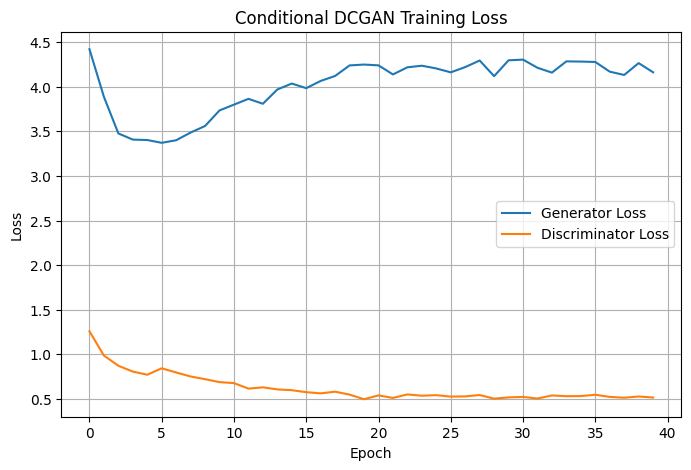

Saved: /kaggle/working/week5_7_conditional_gan_anime_faces/results/week5_7_loss_curve.png


In [13]:
plt.figure(figsize=(8, 5))
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Conditional DCGAN Training Loss")
plt.legend()
plt.grid(True)

loss_path = f"{OUTPUT_DIR}/results/week5_7_loss_curve.png"
plt.savefig(loss_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", loss_path)

Saved: /kaggle/working/week5_7_conditional_gan_anime_faces/results/week5_7_final_samples.png


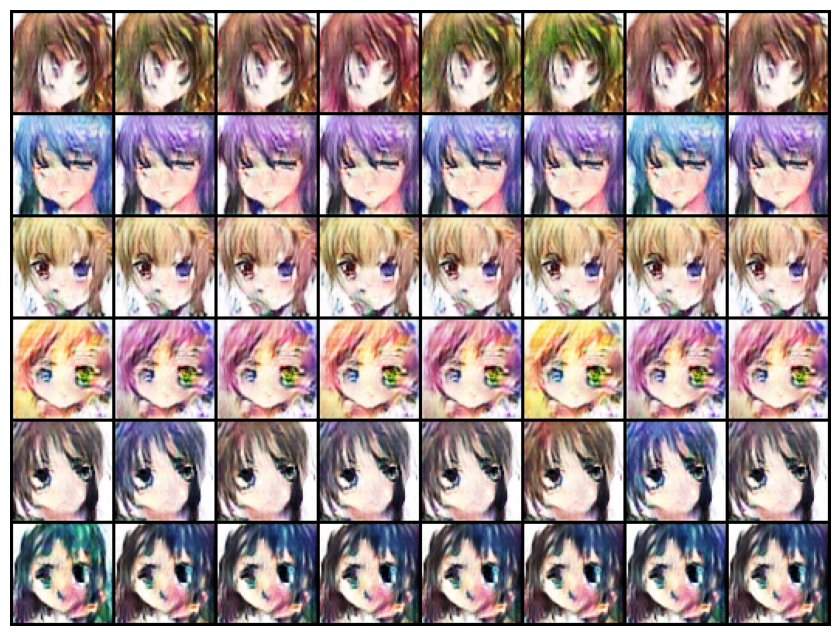

In [14]:
G.eval()

final_noise = torch.randn(num_classes * samples_per_class, latent_dim).to(device)

final_labels = []

for class_idx in range(num_classes):
    final_labels += [class_idx] * samples_per_class

final_labels = torch.tensor(final_labels, dtype=torch.long).to(device)

with torch.no_grad():
    final_images = G(final_noise, final_labels)

final_grid = make_grid(
    final_images,
    nrow=samples_per_class,
    normalize=True
)

final_path = f"{OUTPUT_DIR}/results/week5_7_final_samples.png"
save_image(final_grid, final_path)

print("Saved:", final_path)

from PIL import Image

img = Image.open(final_path)

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [15]:
torch.save(G.state_dict(), f"{OUTPUT_DIR}/models/conditional_dcgan_anime_faces_generator.pth")
torch.save(D.state_dict(), f"{OUTPUT_DIR}/models/conditional_dcgan_anime_faces_discriminator.pth")

print("Models saved.")

Models saved.


In [16]:
labels_df[["image_path", "label"]].to_csv(
    f"{OUTPUT_DIR}/labels.csv",
    index=False
)

print("Saved final labels.csv")

Saved final labels.csv
